# _5. Discussion and comparison_

Main topics of the current notebook is to provide a _**comprehensive evaluation**_ of our anomaly detection methodologies by comparing their performance across different viewed approaches.

We will focus on key metrics such as _**accuracy**_ and _**(average) F-score**_ to quantify the efficience of each technique within the context of its respective approach. The aim being to analyze the relative _**strengths**_ and _**weaknesses**_ of each methodology in accurately detecting anomalies of varying types and severity levels.


In [1]:
# %matplotlib notebook
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

%matplotlib inline

#### _a. Comparison using Accuracy_

In [2]:
methods = ["gmm", "xgb" , "svm_poly" , "svm_rbf" , "nn" , "tabnet"]
result_rows_df = pd.DataFrame({
    "binary": [0.75 , 0.97, 0.91, 0.91, 0.96, 0.94],
    "multi": [-1, 0.94, 0.78, 0.79, 0.88, 0.86],    
    "high-gravity": [-1, 0.99, 0.9, 0.92, 0.98, 0.97],
    "fine-grained": [-1, 0.76, 0.5, 0.47, 0.59, 0.63]   
}, index = methods)

result_rows_df

,binary,multi,high-gravity,fine-grained
gmm,0.75,-1.00,-1.00,-1.00
xgb,0.97,0.94,0.99,0.76
svm_poly,0.91,0.78,0.90,0.50
svm_rbf,0.91,0.79,0.92,0.47
nn,0.96,0.88,0.98,0.59
tabnet,0.94,0.86,0.97,0.63


In [3]:
result_df = result_rows_df.T.copy()
sorted_methods = ["gmm", "svm_poly" , "svm_rbf" , "nn" , "tabnet", "xgb"]
result_df = result_df[sorted_methods]
result_df

,gmm,svm_poly,svm_rbf,nn,tabnet,xgb
binary,0.75,0.91,0.91,0.96,0.94,0.97
multi,-1.00,0.78,0.79,0.88,0.86,0.94
high-gravity,-1.00,0.90,0.92,0.98,0.97,0.99
fine-grained,-1.00,0.50,0.47,0.59,0.63,0.76


In [4]:
classification_labels = ["Binary \n Classification", 
                         "Multi-class \n Classification", 
                         "High-Gravity \n Anomaly Detection", 
                         "Fine-grained \n Anomaly Detection"]

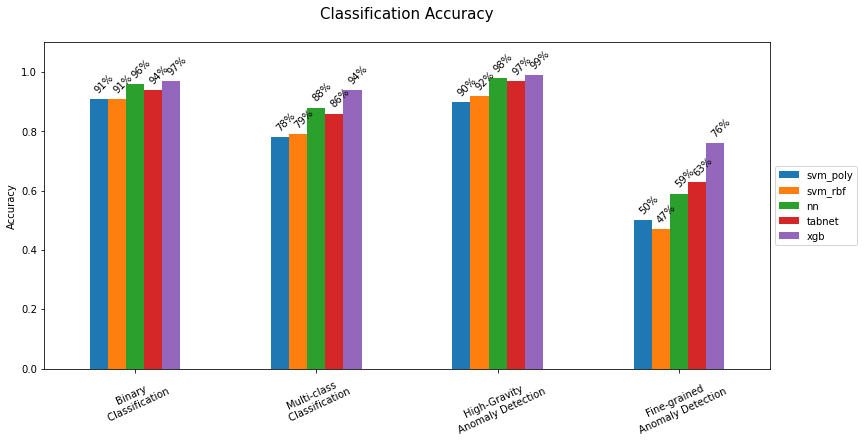

In [5]:
# plt.figure(figsize=(7,10))

ax = result_df.plot(y=sorted_methods[1:], kind="bar", figsize=(13,6), rot=25) 
# ax.set_xlim(pd.Timestamp('2015-02-15'), pd.Timestamp('2015-07-01'))
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
# ax.set_xticks(result_df.index.values, result_df.index.values)
ax.set_xticks([0,1,2,3], classification_labels)
ax.set_title("Classification Accuracy\n ", fontsize=15)
# for container in ax.containers:
#     ax.bar_label(container, fontsize=12, rotation=70)
x_offset = -0.03
y_offset = 0.02
for p in ax.patches:
    b = p.get_bbox()
    val = "{:.0f}%".format(b.y1*100 + b.y0)        
    ax.annotate(val, ((b.x0 + b.x1)/2 + x_offset, b.y1 + y_offset), rotation=45)    
    
plt.legend(loc='center left',  bbox_to_anchor=(1, 0.5));
# plt.legend();

#### _b. Comparison using f1-score_

In [6]:
methods = ["gmm", "xgb" , "svm_poly" , "svm_rbf" , "nn" , "tabnet"]
result_rows_df = pd.DataFrame({
    "binary": [0.43, 0.96, 0.88, 0.88, 0.95, 0.93],
    "multi": [-1, 0.94, 0.78, 0.79, 0.88, 0.86],    
    "high-gravity": [-1, 0.98, 0.82, 0.87, 0.96, 0.95],
    "fine-grained": [-1, 0.71, 0.36, 0.33, 0.43, 0.56]   
}, index = methods)

result_df = result_rows_df.T.copy()
sorted_methods = ["gmm", "svm_poly" , "svm_rbf" , "nn" , "tabnet", "xgb"]
result_df = result_df[sorted_methods]
result_df

,gmm,svm_poly,svm_rbf,nn,tabnet,xgb
binary,0.43,0.88,0.88,0.95,0.93,0.96
multi,-1.00,0.78,0.79,0.88,0.86,0.94
high-gravity,-1.00,0.82,0.87,0.96,0.95,0.98
fine-grained,-1.00,0.36,0.33,0.43,0.56,0.71


In [7]:
result_df = result_rows_df.T.copy()
sorted_methods = ["gmm", "svm_poly" , "svm_rbf" , "nn" , "tabnet", "xgb"]
result_df = result_df[sorted_methods]
result_df

,gmm,svm_poly,svm_rbf,nn,tabnet,xgb
binary,0.43,0.88,0.88,0.95,0.93,0.96
multi,-1.00,0.78,0.79,0.88,0.86,0.94
high-gravity,-1.00,0.82,0.87,0.96,0.95,0.98
fine-grained,-1.00,0.36,0.33,0.43,0.56,0.71


In [8]:
classification_labels = ["Binary \n Classification", 
                         "Multi-class \n Classification", 
                         "High-Gravity \n Anomaly Detection", 
                         "Fine-grained \n Anomaly Detection"]

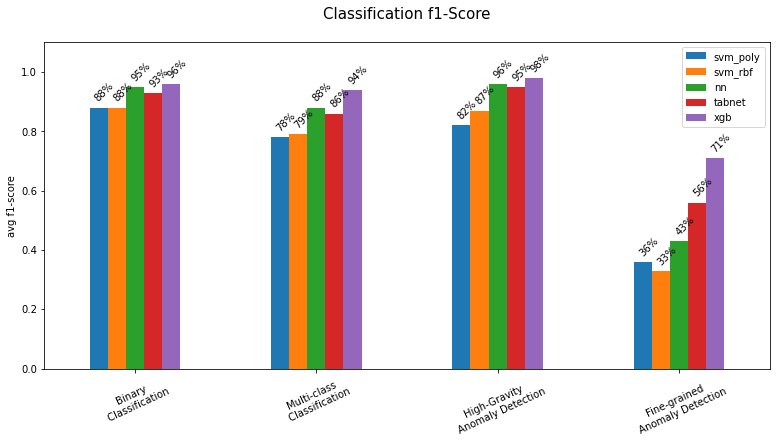

In [9]:
# plt.figure(figsize=(7,10))

ax = result_df.plot(y=sorted_methods[1:], kind="bar", figsize=(13,6), rot=25) 
# ax.set_xlim(pd.Timestamp('2015-02-15'), pd.Timestamp('2015-07-01'))
ax.set_ylim(0, 1.1)
ax.set_ylabel("avg f1-score")
# ax.set_xticks(result_df.index.values, result_df.index.values)
ax.set_xticks([0,1,2,3], classification_labels)
ax.set_title("Classification f1-Score\n ", fontsize=15)
# for container in ax.containers:
#     ax.bar_label(container, fontsize=12, rotation=70)
x_offset = -0.03
y_offset = 0.02
for p in ax.patches:
    b = p.get_bbox()
    val = "{:.0f}%".format(b.y1*100 + b.y0)        
    ax.annotate(val, ((b.x0 + b.x1)/2 + x_offset, b.y1 + y_offset), rotation=45)    
    
# plt.legend(loc='center left',  bbox_to_anchor=(1, 0.5));
plt.legend();